## Initial Setup, Methodology Implementation, and Obtainment of Page Scores & Overall Ranks

In [297]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Outlinks
 - A: B, F
 - B: C, G
 - C: D, G
 - D: A, H
 - E: A, F
 - F: B, I, J
 - G: F, H
 - H: L
 - I: A, E, J
 - J: None
 - K: F, G, J
 - L: G, K

***

In [298]:
n = 12
G = np.zeros((n,n))

In [299]:
letters = 'ABCDEFGHIJKL'
nodes = []

for char in letters:
    nodes.append(char)

In [300]:
# Setting index

idx_dict = {}

for node in nodes:
    idx_dict[node] = nodes.index(node)

idx_dict

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11}

In [301]:
network = {
    'A': ['B', 'F'],
    'B': ['C', 'G'],
    'C': ['D', 'G'],
    'D': ['A', 'G', 'H'],
    'E': ['A', 'F'],
    'F': ['B', 'I', 'J'],
    'G': ['F', 'H'],
    'H': ['L'],
    'I': ['A', 'E', 'J'],
    'J': [], # J has no outlinks
    'K': ['F', 'G', 'J'],
    'L': ['D', 'G', 'K']
}

In [302]:
for node in network:
    i = idx_dict[node] # Index of the current node
    outlinks = network[node] # Outlinks of current node

    if len(outlinks) > 0:
        for out in outlinks:
            j = idx_dict[out] # Index of outlink node

            G[i,j] = 1/len(outlinks) # Initialize entries uniformly by inversely scaling with number of outlinks

In [303]:
print(np.sum(G, axis = 1))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.]


In [304]:
# Eigenvalue Decomposition

eigenvalues, eigenvectors = np.linalg.eig(G.T)

eigenvalues = np.real(eigenvalues)

max_eigenval = np.max(eigenvalues)
max_eigenval_idx = np.argmax(eigenvalues)

max_eigenvec = np.real(eigenvectors[:, max_eigenval_idx])

print(max_eigenval)

0.9112816256781208


No, we did not get a max eigenvalue of 1.

In [305]:
print(max_eigenvec)

[-0.17255429 -0.2585716  -0.1418725  -0.21791626 -0.05995033 -0.44806322
 -0.49073629 -0.34896666 -0.16389489 -0.27508221 -0.14007397 -0.38294052]


No, the max eigenvector has all negative entries.

In [306]:
# Fix Dangling Nodes

for node in network:
    if node == 'J':
        i = idx_dict[node]
        for j in range(n):
            G[i, j] = 1/n

np.sum(G, axis = 1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [307]:
eigenvalues, eigenvectors = np.linalg.eig(G.T)

eigenvalues = np.real(eigenvalues)

max_eigenval = np.max(eigenvalues)
max_eigenval_idx = np.argmax(eigenvalues)

max_eigenvec = np.real(eigenvectors[:, max_eigenval_idx])

print(max_eigenval)

1.0000000000000009


Yes, now the max eigenvalue is 1.

In [308]:
print(max_eigenvec)

[-0.19579607 -0.27109886 -0.15878395 -0.2230316  -0.08096813 -0.44989889
 -0.48080478 -0.33798078 -0.17320082 -0.2788143  -0.14363963 -0.36121531]


No, the entries are still all negative, but we can scale by -1, because relative importance is preserved.

In [309]:
# Normalizing eigenvector

max_eigenvec = -1 * max_eigenvec/np.sum(np.abs(max_eigenvec)) # np.sum(np.abs(max_eigenvec)) calculates the l-1 norm

print(max_eigenvec)

[0.06205439 0.08592039 0.050324   0.07068625 0.02566154 0.14258816
 0.15238328 0.10711753 0.05489319 0.08836568 0.04552425 0.11448134]


In [310]:
# rank_dict = {}

# for i in range(len(max_eigenvec)):
#     rank_dict[nodes[i]] = max_eigenvec[i]

# print(rank_dict)

sorted_idx = np.argsort(max_eigenvec)[::-1]
print(sorted_idx)


[ 6  5 11  7  9  1  3  0  8  2 10  4]


In [311]:
max_eigenvec = sorted(max_eigenvec, reverse = True)

print(max_eigenvec)

[np.float64(0.152383281225438), np.float64(0.14258816131905755), np.float64(0.11448133722250362), np.float64(0.10711753095907635), np.float64(0.08836567516112688), np.float64(0.08592038845126011), np.float64(0.07068625224879042), np.float64(0.06205439016296103), np.float64(0.05489319336977974), np.float64(0.050324000489057365), np.float64(0.04552425200426181), np.float64(0.025661537386687146)]


In [312]:
# Applying Power Method

eps = 1e-8 # Specifying tolerance for convergence

max_iter = 100 # Setting max number of iterations

pi_prev = np.ones(12)/n # Initial vector pi_0, which is a normalized vector of ones, with length 12

for j in range(max_iter):
    pi_curr = G.T @ pi_prev # pi_j = G^T * pi_{j-1}

    res = np.sum(np.abs(pi_curr - pi_prev)) # Residual

    # If the residual/error is less than or equal to the tolerance, we stop and record the iteration j at which it stops
    # We use j+1 since indexing starts at 0
    if res <= eps:
        print(f'Converged at iteration {j+1}')
        break

    pi_prev = pi_curr # The current vector becomes the previous for the next iteration

Converged at iteration 58


In [313]:
print(pi_curr)

[0.06205439 0.08592039 0.050324   0.07068625 0.02566154 0.14258816
 0.15238328 0.10711753 0.05489319 0.08836568 0.04552425 0.11448134]


Using the power method, we got the exact same max eigenvector as we did earlier. We used a total of 58 iterations.

In [314]:
#Save the PageRank vector from the fixed Google matrix G
pi_fixed_G = pi_curr.copy()

In [315]:
alpha = 0.85

E = np.outer(np.ones(n), np.ones(n))/n

G_tilde = alpha * G + (1-alpha) * E

print(np.sum(G_tilde, axis=1))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [316]:
# Applying Power Method for G_tilde

pi_prev = np.ones(12)/n

for j in range(max_iter):
    pi_curr = G_tilde.T @ pi_prev # pi_j = G_tilde^T * pi_{j-1}

    res = np.sum(np.abs(pi_curr - pi_prev)) # Residual

    # If the residual/error is less than or equal to the tolerance, we stop and record the iteration j at which it stops
    # We use j+1 since indexing starts at 0
    if res <= eps:
        print(f'Converged at iteration {j+1}')
        break

    pi_prev = pi_curr # The current vector becomes the previous for the next iteration

Converged at iteration 38


In [317]:
print(pi_curr)

[0.07041128 0.08776822 0.05602505 0.07191504 0.03511253 0.13807012
 0.14322204 0.09996885 0.05784342 0.08786197 0.0481044  0.10369708]


In [318]:
print(np.argsort(pi_curr)[::-1])
print(sorted_idx)

[ 6  5 11  7  9  1  3  0  8  2 10  4]
[ 6  5 11  7  9  1  3  0  8  2 10  4]


The rankings of webpages from G_tilde and G are the same.

In [319]:
#Save the PageRank vector from the teleportation matrix G_tilde
pi_tilde = pi_curr.copy()

***

## Term-Document Matrix and Page Searching

In [320]:
# Dictionary of webpage titles

webpage_titles = {
    'A': 'Trees For All',
    'B': 'The Weeping Willow',
    'C': 'Leaf Fall',
    'D': 'Shady Place',
    'E': 'The Prickly Pine',
    'F': 'Good Wood',
    'G': 'Lumber Jack Man',
    'H': 'Timber!',
    'I': 'Fine Grains',
    'J': 'The Warped Board',
    'K': 'Evergreen Plants',
    'L': 'Sappy Planks'
}

# Dictionary of webpage keywords
key_words_dict = {
    'A': str.split("Ash, Butternut, Cherry, Elm, Katsura, Magnolia, Teak, Ginkgo, Eucalyptus", ', '),
    'B': str.split("Butternut, Fir, Hickory, Magnolia, Pine, Willow, Redwood, Sassafras", ', '),
    'C': str.split("Ash, Elm, Hickory, Katsura, Oak, Ginkgo, Redwood, Eucalyptus", ', '),
    'D': str.split("Butternut, Cherry, Fir, Spruce, Teak, Aspen, Sassafras", ', '),
    'E': str.split("Cherry, Hickory, Oak, Pine, Willow, Redwood, Eucalyptus", ', '),
    'F': str.split("Ash, Fir, Magnolia, Spruce, Ginkgo, Redwood, Aspen, Sassafras", ', '),
    'G': str.split("Ash, Butternut, Oak, Spruce, Ginkgo, Redwood", ', '),
    'H': str.split("Ash, Cherry, Hickory, Willow, Redwood, Aspen, Eucalyptus", ', '),
    'I': str.split("Elm, Fir, Katsura, Magnolia, Pine, Spruce, Sassafras, Eucalyptus", ', '),
    'J': str.split("Magnolia, Oak, Willow, Redwood, Aspen, Sassafras, Eucalyptus", ', '),
    'K': str.split("Cherry, Elm, Fir, Hickory, Teak, Ginkgo, Redwood, Sassafras", ', '),
    'L': str.split("Butternut, Elm, Katsura, Oak, Pine, Spruce, Teak, Ginkgo, Aspen, Sassafras", ', ')
}

In [321]:
# Initializing Term-Document Matrix

all_words = []

for char in nodes:
    all_words += key_words_dict[char]

# Finding all unique words
unique_words = np.unique(all_words)

num_terms = len(unique_words) # Number of unique terms
num_docs = len(key_words_dict) # Number of webpages

# Term-Document Matrix
T = np.zeros((num_terms, num_docs))

In [322]:
# Row (Terms): i
# Col (Webpages): j

# Nested loop goes through every unique term and checks if each is present in the webpage's keywords. 
# If so, a 1 is assigned to the corresponding position (i, j), else it stays a zero.

for i in range(num_terms): # All unique terms (Correspond to rows in the matrix)
    for j in range(num_docs): # All webpages (Correspond to columns in the matrix)
        # Checks to see if the term is present in the document's keywords, assigning a 1 in the corresponding position if the term is present.
        if unique_words[i] in key_words_dict[nodes[j]]:
            T[i, j] = 1

In [323]:
unique_words

array(['Ash', 'Aspen', 'Butternut', 'Cherry', 'Elm', 'Eucalyptus', 'Fir',
       'Ginkgo', 'Hickory', 'Katsura', 'Magnolia', 'Oak', 'Pine',
       'Redwood', 'Sassafras', 'Spruce', 'Teak', 'Willow'], dtype='<U10')

In [324]:
T

array([[1., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.],
       [1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1.],
       [1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0.],
       [1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1.],
       [1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.],
       [0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0.],
       [1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1.],
       [0., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0.],
       [1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1.],
       [1., 1., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0.],
       [0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1.],
       [0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1.],
       [0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.],
       [0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1.],
       [1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 1., 0., 0., 1., 0.,

### Search Queries:
- Single: "Eucalyptus"
- AND: "Teak AND Ginkgo"
- OR: "Katsura OR Magnolia"
- BUT NOT: "Butternut BUT NOT Cherry"

In [325]:
# Single Search

q_single = np.zeros(num_terms) # Query Vector
query_idx = np.where(unique_words == 'Eucalyptus')[0]
q_single[query_idx] = 1

print('Query Vector:', q_single)

d_single = T.T @ q_single # Search Result Vector

print('Search Result:', d_single)


Query Vector: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Search Result: [1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0.]


In the query vector, 1 stands for the keyword we are searching for and 0 for otherwise. Thus, in the search result vector, intepretation is very straightforward, as the 1s represent the pages containing the term, and the 0s represent the ones that don't. Thus, we focus on the 1s in the search result vector to find the responsive webpages.

From the single search of "Eucalyptus", webpages A, C, E, H, I, J were responsive. 

In [326]:
q_and = np.zeros(num_terms) # Query Vector
query_idx1 = np.where(unique_words == 'Teak')[0]
query_idx2 = np.where(unique_words == 'Ginkgo')[0]

q_and[query_idx1] = 1
q_and[query_idx2] = 1

print('Query Vector:', q_and)

d_and = T.T @ q_and # Search Result Vector

print('Search Result:', d_and)

Query Vector: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
Search Result: [2. 0. 1. 1. 0. 1. 1. 0. 0. 0. 2. 2.]


In the query vector, like single search, the 1s and 0s denote the keywords we want and don't necessarily need. The difference comes in the search result vector. We interpret 2s as webpages that contain both "Teak" and "Gingko", 1s as webpages that only contain one of them, and 0s as webpages that contain neither.

Thus, we focus on the 2s in the search result vector to find the responsive webpages.

From the AND search result for "Teak AND Ginkgo", webpages A, K, L were responsive.

In [327]:
q_or = np.zeros(num_terms) # Query Vector
query_idx1 = np.where(unique_words == 'Katsura')[0]
query_idx2 = np.where(unique_words == 'Magnolia')[0]

q_or[query_idx1] = 1
q_or[query_idx2] = 1

print('Query Vector:', q_or)

d_or = T.T @ q_or # Search Result Vector

print('Search Result:', d_or)

Query Vector: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
Search Result: [2. 1. 1. 0. 0. 1. 0. 0. 2. 1. 0. 1.]


The logic for the query vector is similar as the previous two searches. The search result vector is also similar in logic to the AND search, but the logic differs in how we decide the responsive webpages. In the search result vector, the 2s represent the webpages containing both "Katsura" and "Magnolia", the 1s represent webpages containing one of them, and the 0s represent webpages containing neither.

Thus, we focus on the webpages with 1s and 2s since the condition is that the webpage only needs at least one of the terms.

From the OR search result for "Katsura OR Magnolia", webpages A, B, C, F, I, J, L were responsive.

In [328]:
q_butnot= np.zeros(num_terms) # Query Vector
query_idx1 = np.where(unique_words == 'Butternut')[0]
query_idx2 = np.where(unique_words == 'Cherry')[0]

q_butnot[query_idx1] = 1
q_butnot[query_idx2] = -1

print('Query Vector:', q_butnot)

d_butnot = T.T @ q_butnot # Search Result Vector

print('Search Result:', d_butnot)

Query Vector: [ 0.  0.  1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Search Result: [ 0.  1.  0.  0. -1.  0.  1. -1.  0.  0. -1.  1.]


In the query vector, we represented the term we want with 1 and the term we want to exclude with -1. In the search result, 1 means that the webpage contains "Butternut" but not "Cherry", 0 means that the page has both "Butternut" and "Cherry", and -1 indicates that the webpage has "Cherry" but not "Butternut".

Thus, we only looked for the webpages with the corresponding value of 1 in the search result vector.

From the BUT NOT search result for "Butternut BUT NOT Cherry", webpages B, G, L were responsive.

***

## Ranking the pages from the Searches

In [329]:
# Dictionary of Webpages and their indexes
print(idx_dict) 

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11}


In [330]:
# Reversing the dictionary above, so that we can find the corresponding webpages by indices

idx_dict_reversed = {}

for page, idx in idx_dict.items():
    idx_dict_reversed[idx] = page

print(idx_dict_reversed)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L'}


In [331]:
searched_idx = np.where(d_single == 1)[0] # Indices corresponding to the responsive webpages for "Eucalyptus"

print('Indices of Responsive Pages:', searched_idx)

searched_scores = pi_curr[searched_idx] # Scores corresponding to the responsive webpages

print('Scores of Responsive Webpages:', searched_scores)

rank_idx = np.argsort(searched_scores)[::-1] # Obtain the rankings based on the scores in descending order

pages_ranked = searched_idx[rank_idx] # The pages ranked by the scores in descending order

print('Pages Ranked:', pages_ranked)

Indices of Responsive Pages: [0 2 4 7 8 9]
Scores of Responsive Webpages: [0.07041128 0.05602505 0.03511253 0.09996885 0.05784342 0.08786197]
Pages Ranked: [7 9 0 8 2 4]


In [332]:
print('Ranking of Webpages for Single Search for "Eucalyptus":\n')

# Displaying ranking of responsive webpages
for i in range(len(pages_ranked)):
    page = idx_dict_reversed[pages_ranked[i]]
    print(f'{i+1}. Webpage {page}: {webpage_titles[page]}')

Ranking of Webpages for Single Search for "Eucalyptus":

1. Webpage H: Timber!
2. Webpage J: The Warped Board
3. Webpage A: Trees For All
4. Webpage I: Fine Grains
5. Webpage C: Leaf Fall
6. Webpage E: The Prickly Pine


In [333]:
searched_idx = np.where(d_and == 2)[0] # Indices corresponding to the responsive webpages for "Teak AND Gingko"

print('Indices of Responsive Pages:', searched_idx)

searched_scores = pi_curr[searched_idx] # Scores corresponding to the responsive webpages

print('Scores of Responsive Webpages:', searched_scores)

rank_idx = np.argsort(searched_scores)[::-1] # Obtain the rankings based on the scores in descending order

pages_ranked = searched_idx[rank_idx] # The pages ranked by the scores in descending order

print('Pages Ranked:', pages_ranked)

Indices of Responsive Pages: [ 0 10 11]
Scores of Responsive Webpages: [0.07041128 0.0481044  0.10369708]
Pages Ranked: [11  0 10]


In [334]:
print('Ranking of Webpages for AND Search "Teak AND Gingko":\n')

# Displaying ranking of responsive webpages
for i in range(len(pages_ranked)):
    page = idx_dict_reversed[pages_ranked[i]]
    print(f'{i+1}. Webpage {page}: {webpage_titles[page]}')

Ranking of Webpages for AND Search "Teak AND Gingko":

1. Webpage L: Sappy Planks
2. Webpage A: Trees For All
3. Webpage K: Evergreen Plants


In [335]:
searched_idx = np.where((d_or == 2) | (d_or == 1))[0] # Indices corresponding to the responsive webpages for "Katsura OR Magnolia"

print('Indices of Responsive Pages:', searched_idx)

searched_scores = pi_curr[searched_idx] # Scores corresponding to the responsive webpages

print('Scores of Responsive Webpages:', searched_scores)

rank_idx = np.argsort(searched_scores)[::-1] # Obtain the rankings based on the scores in descending order

pages_ranked = searched_idx[rank_idx] # The pages ranked by the scores in descending order

print('Pages Ranked:', pages_ranked)

Indices of Responsive Pages: [ 0  1  2  5  8  9 11]
Scores of Responsive Webpages: [0.07041128 0.08776822 0.05602505 0.13807012 0.05784342 0.08786197
 0.10369708]
Pages Ranked: [ 5 11  9  1  0  8  2]


In [336]:
print('Ranking of Webpages for OR Search "Katsura OR Magnolia":\n')

# Displaying ranking of responsive webpages
for i in range(len(pages_ranked)):
    page = idx_dict_reversed[pages_ranked[i]]
    print(f'{i+1}. Webpage {page}: {webpage_titles[page]}')

Ranking of Webpages for OR Search "Katsura OR Magnolia":

1. Webpage F: Good Wood
2. Webpage L: Sappy Planks
3. Webpage J: The Warped Board
4. Webpage B: The Weeping Willow
5. Webpage A: Trees For All
6. Webpage I: Fine Grains
7. Webpage C: Leaf Fall


In [337]:
searched_idx = np.where(d_butnot == 1)[0] # Indices corresponding to the responsive webpages for "Buttermilk BUT NOT Cherry"

print('Indices of Responsive Pages:', searched_idx)

searched_scores = pi_curr[searched_idx] # Scores corresponding to the responsive webpages

print('Scores of Responsive Webpages:', searched_scores)

rank_idx = np.argsort(searched_scores)[::-1] # Obtain the rankings based on the scores in descending order

pages_ranked = searched_idx[rank_idx] # The pages ranked by the scores in descending order

print('Pages Ranked:', pages_ranked)

Indices of Responsive Pages: [ 1  6 11]
Scores of Responsive Webpages: [0.08776822 0.14322204 0.10369708]
Pages Ranked: [ 6 11  1]


In [338]:
print('Ranking of Webpages for BUT NOT Search "Buttermilk BUT NOT Cherry":\n')

# Displaying ranking of responsive webpages
for i in range(len(pages_ranked)):
    page = idx_dict_reversed[pages_ranked[i]]
    print(f'{i+1}. Webpage {page}: {webpage_titles[page]}')

Ranking of Webpages for BUT NOT Search "Buttermilk BUT NOT Cherry":

1. Webpage G: Lumber Jack Man
2. Webpage L: Sappy Planks
3. Webpage B: The Weeping Willow


In [339]:
# Save the final PageRank vector from G_tilde
# In the previous code, pi_curr is the final result after using G_tilde.
pi_tilde = pi_curr.copy()

pi_tilde

array([0.07041128, 0.08776822, 0.05602505, 0.07191504, 0.03511253,
       0.13807012, 0.14322204, 0.09996885, 0.05784342, 0.08786197,
       0.0481044 , 0.10369708])

In [340]:
# Create a clean final PageRank table
final_pagerank_table = pd.DataFrame({
    "Page": nodes,
    "Page Title": [webpage_titles[node] for node in nodes],
    "PageRank Score": pi_tilde
})

# Sort from highest PageRank to lowest PageRank
final_pagerank_table = final_pagerank_table.sort_values(
    by="PageRank Score",
    ascending=False
).reset_index(drop=True)

# Add rank number
final_pagerank_table["Rank"] = final_pagerank_table.index + 1

final_pagerank_table

,Page,Page Title,PageRank Score,Rank
0,G,Lumber Jack Man,0.143222,1
1,F,Good Wood,0.138070,2
2,L,Sappy Planks,0.103697,3
3,H,Timber!,0.099969,4
4,J,The Warped Board,0.087862,5
5,B,The Weeping Willow,0.087768,6
6,D,Shady Place,0.071915,7
7,A,Trees For All,0.070411,8
8,I,Fine Grains,0.057843,9
9,C,Leaf Fall,0.056025,10


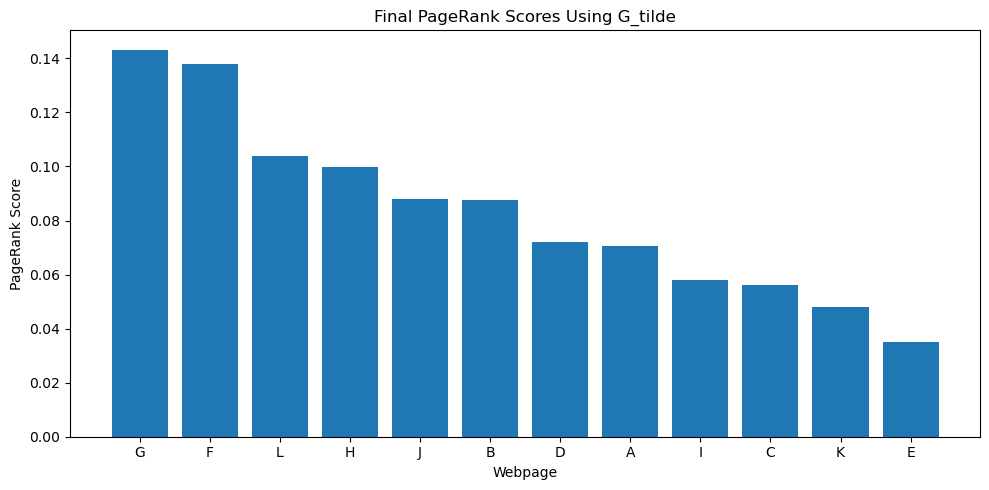

In [341]:
#Bar graph for the final PageRank scores
plt.figure(figsize=(10, 5))
plt.bar(final_pagerank_table["Page"], final_pagerank_table["PageRank Score"])
plt.xlabel("Webpage")
plt.ylabel("PageRank Score")
plt.title("Final PageRank Scores Using G_tilde")
plt.tight_layout()
plt.show()

In [342]:
#Final summary for notebook output

top_page = final_pagerank_table.loc[0, "Page"]
top_title = final_pagerank_table.loc[0, "Page Title"]
top_score = final_pagerank_table.loc[0, "PageRank Score"]

print(f"The highest ranked webpage is {top_page}: {top_title}.")
print(f"Its PageRank score is {top_score:}.")
print("This final ranking uses G_tilde, which includes teleportation with alpha = 0.85.")

The highest ranked webpage is G: Lumber Jack Man.
Its PageRank score is 0.1432220421104659.
This final ranking uses G_tilde, which includes teleportation with alpha = 0.85.


In [343]:
print("Sum of PageRank scores:", pi_tilde.sum())
print("All scores nonnegative:", np.all(pi_tilde >= 0))

Sum of PageRank scores: 0.9999999999999996
All scores nonnegative: True


In [344]:
#Compare rankings from fixed G and G_tilde

comparison_table = pd.DataFrame({"Page": nodes, "Page Title": [webpage_titles[node] for node in nodes], "Score from fixed G": pi_fixed_G, "Score from G_tilde": pi_tilde})

comparison_table["Rank from fixed G"] = comparison_table["Score from fixed G"].rank(ascending=False, method="first").astype(int)

comparison_table["Rank from G_tilde"] = comparison_table["Score from G_tilde"].rank(ascending=False, method="first").astype(int)

comparison_table = comparison_table.sort_values("Rank from G_tilde").reset_index(drop=True)

comparison_table

,Page,Page Title,Score from fixed G,Score from G_tilde,Rank from fixed G,Rank from G_tilde
0,G,Lumber Jack Man,0.152383,0.143222,1,1
1,F,Good Wood,0.142588,0.138070,2,2
2,L,Sappy Planks,0.114481,0.103697,3,3
3,H,Timber!,0.107118,0.099969,4,4
4,J,The Warped Board,0.088366,0.087862,5,5
5,B,The Weeping Willow,0.085920,0.087768,6,6
6,D,Shady Place,0.070686,0.071915,7,7
7,A,Trees For All,0.062054,0.070411,8,8
8,I,Fine Grains,0.054893,0.057843,9,9
9,C,Leaf Fall,0.050324,0.056025,10,10


In [345]:
query_summary = pd.DataFrame({"Query": ["Eucalyptus", "Teak AND Ginkgo", "Katsura OR Magnolia", "Butternut BUT NOT Cherry"],
    "Final ranked pages": ["H, J, A, I, C, E", "L, A, K", "F, L, J, B, A, I, C", "G, L, B"]})

query_summary

,Query,Final ranked pages
0,Eucalyptus,"H, J, A, I, C, E"
1,Teak AND Ginkgo,"L, A, K"
2,Katsura OR Magnolia,"F, L, J, B, A, I, C"
3,Butternut BUT NOT Cherry,"G, L, B"
